# Renewables Forecasting & Clustering

Two analyses using the merged renewables dataset:
1. **ARIMA forecasting** — forecast Denmark's renewable electricity share using its own history
2. **K-means clustering** — group ~100+ countries by their renewable electricity profile (2010–2022)

**Data source:** `merged_renewables_data.csv`

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## 2. Load Data

In [2]:
RENEWABLES = '../../../data/derived_renewables/merged_renewables_data.csv'
AGGREGATES = {
    'Africa','Asia','Europe','North America','South America','World',
    'European Union (27)','European Union (28)','European Union (27) countries',
    'Lower-middle-income countries','Upper-middle-income countries',
    'High-income countries','Low-income countries','Middle-income countries',
    'OECD','Non-OECD',
}

ren = pd.read_csv(RENEWABLES)
print(f'Full dataset: {ren.shape}  —  {ren["Entity"].nunique()} entities, years {ren["Year"].min()}–{ren["Year"].max()}')
ren.head()

Full dataset: (8851, 11)  —  251 entities, years 1965–2022


,Entity,Code,Year,Electricity from wind (TWh),Electricity from hydro (TWh),Electricity from solar (TWh),Other renewables including bioenergy (TWh),Renewables (% electricity),Hydro (% electricity),Wind (% electricity),Solar (% electricity)
0,Afghanistan,AFG,2000,0.0,0.31,0.0,0.0,65.957440,65.957440,0.0,0.0
1,Afghanistan,AFG,2001,0.0,0.50,0.0,0.0,84.745766,84.745766,0.0,0.0
2,Afghanistan,AFG,2002,0.0,0.56,0.0,0.0,81.159424,81.159424,0.0,0.0
3,Afghanistan,AFG,2003,0.0,0.63,0.0,0.0,67.021280,67.021280,0.0,0.0
4,Afghanistan,AFG,2004,0.0,0.56,0.0,0.0,62.921350,62.921350,0.0,0.0


## 3. ARIMA Forecast: Denmark Renewable Electricity Share

**Setup:** Hold out the last 8 annual observations as the test set. Select ARIMA(p,d,q) by lowest AIC over p,d,q ∈ {0,1,2} on the training window. Plot observed vs. forecast with a 95% confidence interval.

**Interpretation:** How well does past renewable share predict near-term future share? A tight CI means the trend is stable; a wide CI means high uncertainty.

In [3]:
def choose_arima_order(series, p_range=range(0,3), d_range=range(0,3), q_range=range(0,3)):
    best_order, best_aic = (1,1,0), np.inf
    for p in p_range:
        for d in d_range:
            for q in q_range:
                try:
                    fit = ARIMA(series, order=(p,d,q)).fit()
                    if np.isfinite(fit.aic) and fit.aic < best_aic:
                        best_aic, best_order = fit.aic, (p,d,q)
                except Exception:
                    continue
    return best_order

In [4]:
country     = 'Denmark'
value_col   = 'Renewables (% electricity)'
test_horizon = 8

country_df = (
    ren.loc[ren['Entity'] == country, ['Year', value_col]]
    .dropna().sort_values('Year').reset_index(drop=True)
)

periods = pd.PeriodIndex(country_df['Year'].astype(int), freq='Y')
ts = pd.Series(country_df[value_col].to_numpy(), index=periods, name=value_col)

train, test = ts.iloc[:-test_horizon], ts.iloc[-test_horizon:]
order = choose_arima_order(train)
print(f'Best ARIMA order: {order}')

fitted = ARIMA(train, order=order).fit()
fc_res  = fitted.get_forecast(steps=test_horizon)
forecast = pd.Series(fc_res.predicted_mean.to_numpy(), index=test.index)
conf = fc_res.conf_int()

mae  = float(np.mean(np.abs(test - forecast)))
rmse = float(np.sqrt(np.mean((test - forecast)**2)))
mape = float(np.mean(np.abs((test - forecast) / test)) * 100)
print(f'MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%  AIC={fitted.aic:.2f}')

Best ARIMA order: (0, 2, 2)
MAE=4.824  RMSE=5.831  MAPE=6.57%  AIC=153.37


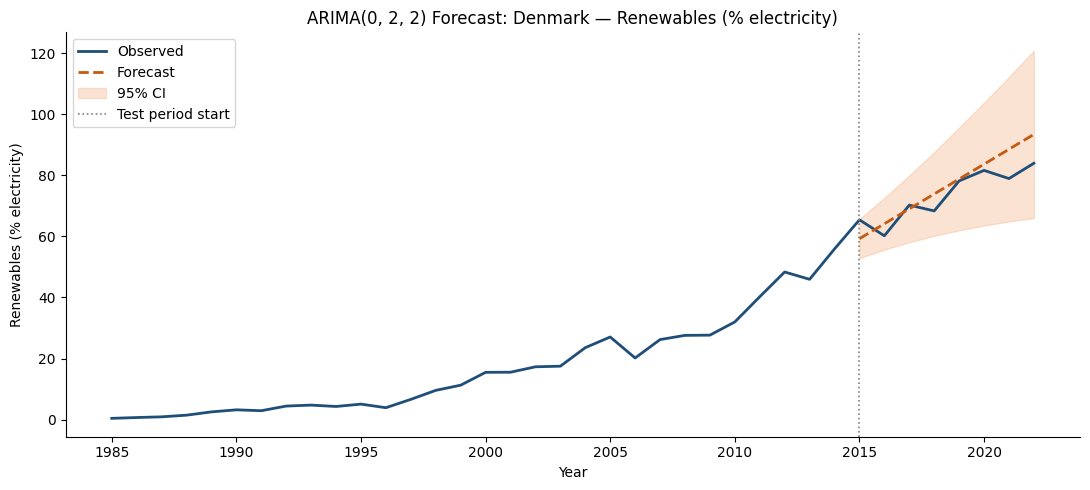

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ts.index.year, ts.values, label='Observed', linewidth=2, color='#1f4e79')
ax.plot(forecast.index.year, forecast.values, label='Forecast', linewidth=2, linestyle='--', color='#c55a11')
ax.fill_between(forecast.index.year,
                conf.iloc[:,0].to_numpy(), conf.iloc[:,1].to_numpy(),
                color='#f4b183', alpha=0.35, label='95% CI')
ax.axvline(test.index.min().year, color='gray', linestyle=':', linewidth=1.2, label='Test period start')
ax.set_title(f'ARIMA{order} Forecast: {country} — {value_col}')
ax.set_xlabel('Year')
ax.set_ylabel(value_col)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
pd.DataFrame([{'Country': country, 'Series': value_col, 'Order': str(order),
               'Train end': int(train.index.max().year),
               'Test start': int(test.index.min().year),
               'MAE': round(mae,3), 'RMSE': round(rmse,3),
               'MAPE (%)': round(mape,2), 'AIC': round(fitted.aic,2)}])

,Country,Series,Order,Train end,Test start,MAE,RMSE,MAPE (%),AIC
0,Denmark,Renewables (% electricity),"(0, 2, 2)",2014,2015,4.824,5.831,6.57,153.37


## 4. K-means Clustering: Countries by Renewable Profile

**Sample:** Countries (not aggregates) with ≥10 non-missing annual observations from 2010–2022.

**Features per country:** average renewable share, latest share, linear growth rate, avg wind/solar/hydro share, share variability.

**Method:** Standardize features, then K-means with k=3. PCA used for visualization only.

In [7]:
country_ren = ren[~ren['Entity'].isin(AGGREGATES) & ren['Code'].notna()].copy()
recent = country_ren[(country_ren['Year'] >= 2010) & (country_ren['Year'] <= 2022)].dropna(
    subset=['Renewables (% electricity)','Wind (% electricity)',
            'Solar (% electricity)','Hydro (% electricity)'])

counts = recent.groupby('Entity')['Year'].count()
recent = recent[recent['Entity'].isin(counts[counts >= 10].index)].copy()
print(f'Countries in clustering sample: {recent["Entity"].nunique()}')

Countries in clustering sample: 206


In [8]:
def annual_slope(group, col):
    x = group['Year'].to_numpy(dtype=float)
    y = group[col].to_numpy(dtype=float)
    return float(np.polyfit(x, y, 1)[0]) if len(np.unique(x)) > 1 else np.nan

features = recent.groupby('Entity').apply(
    lambda g: pd.Series({
        'avg_renew_share':    g['Renewables (% electricity)'].mean(),
        'latest_renew_share': g.sort_values('Year')['Renewables (% electricity)'].iloc[-1],
        'renew_share_growth': annual_slope(g, 'Renewables (% electricity)'),
        'avg_wind_share':     g['Wind (% electricity)'].mean(),
        'avg_solar_share':    g['Solar (% electricity)'].mean(),
        'avg_hydro_share':    g['Hydro (% electricity)'].mean(),
        'renew_share_sd':     g['Renewables (% electricity)'].std(),
    }), include_groups=False
).dropna().reset_index()

feature_cols = [c for c in features.columns if c != 'Entity']
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
features['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, features['cluster'])
print(f'Silhouette score: {sil:.3f}')

Silhouette score: 0.449


In [9]:
cluster_summary = (
    features.groupby('cluster')
    .agg(n_countries=('Entity','count'),
         avg_renew_share=('avg_renew_share','mean'),
         latest_renew_share=('latest_renew_share','mean'),
         renew_share_growth=('renew_share_growth','mean'),
         avg_wind_share=('avg_wind_share','mean'),
         avg_solar_share=('avg_solar_share','mean'),
         avg_hydro_share=('avg_hydro_share','mean'))
    .round(2).reset_index()
)
cluster_summary

,cluster,n_countries,avg_renew_share,latest_renew_share,renew_share_growth,avg_wind_share,avg_solar_share,avg_hydro_share
0,0,36,30.43,41.46,2.07,9.64,3.80,11.89
1,1,64,72.97,72.24,-0.26,1.44,0.73,65.07
2,2,106,8.76,10.46,0.21,0.91,0.80,5.76


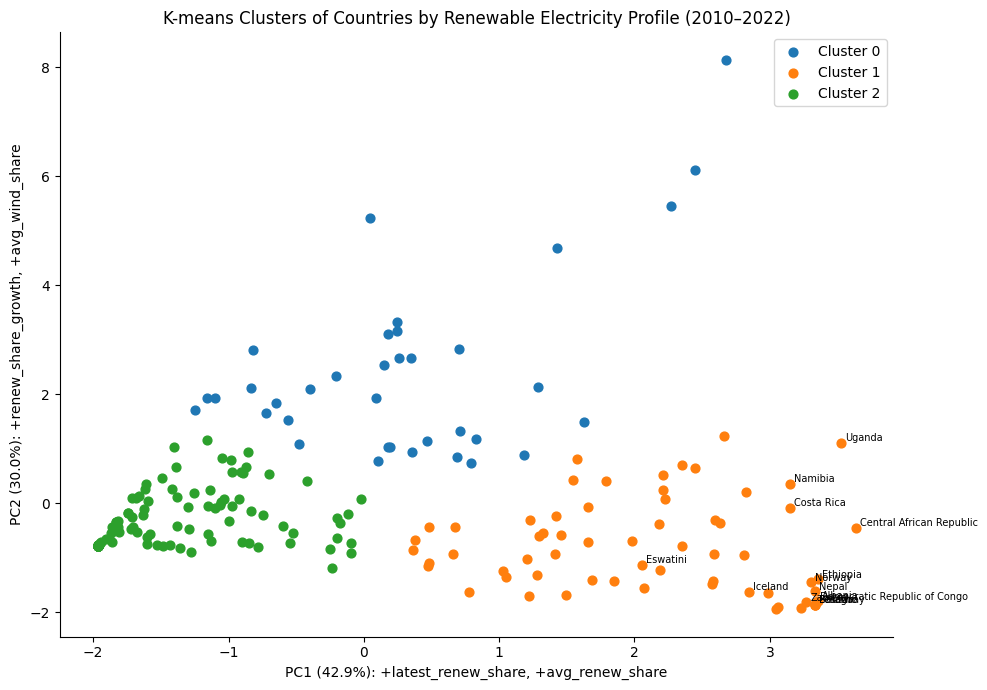

In [10]:
pca = PCA(n_components=2, random_state=42)
coords   = pca.fit_transform(X_scaled)
loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=['PC1','PC2'])

def pc_label(pc_name):
    top = loadings[pc_name].sort_values(key=lambda s: s.abs(), ascending=False).head(2)
    parts = [f"{'+'if v>=0 else '-'}{i}" for i,v in top.items()]
    pct = pca.explained_variance_ratio_[0 if pc_name=='PC1' else 1]*100
    return f"{pc_name} ({pct:.1f}%): " + ", ".join(parts)

plot_df = features.copy()
plot_df['pc1'], plot_df['pc2'] = coords[:,0], coords[:,1]

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.get_cmap('tab10')
for cluster in sorted(plot_df['cluster'].unique()):
    sub = plot_df[plot_df['cluster']==cluster]
    ax.scatter(sub['pc1'], sub['pc2'], s=40, color=cmap(cluster), label=f'Cluster {cluster}')

for _, row in plot_df.nlargest(15, 'latest_renew_share').iterrows():
    ax.text(row['pc1']+0.03, row['pc2']+0.03, row['Entity'], fontsize=7)

ax.set_title('K-means Clusters of Countries by Renewable Electricity Profile (2010–2022)')
ax.set_xlabel(pc_label('PC1'))
ax.set_ylabel(pc_label('PC2'))
ax.legend()
plt.tight_layout()
plt.show()

## 5. PCA Loadings

Shows which features most drive each principal component axis in the cluster plot.

In [11]:
loadings.round(3)

,PC1,PC2
avg_renew_share,0.566,-0.101
latest_renew_share,0.567,0.025
renew_share_growth,0.016,0.566
avg_wind_share,0.116,0.470
avg_solar_share,0.016,0.461
avg_hydro_share,0.525,-0.258
renew_share_sd,0.261,0.412


## 6. Country-level Cluster Assignments

Full list of countries and their cluster, sorted by cluster and renewable share.

In [12]:
(features[['Entity','cluster','avg_renew_share','latest_renew_share','renew_share_growth',
            'avg_wind_share','avg_solar_share','avg_hydro_share']]
 .sort_values(['cluster','latest_renew_share'], ascending=[True,False])
 .reset_index(drop=True))

,Entity,cluster,avg_renew_share,latest_renew_share,renew_share_growth,avg_wind_share,avg_solar_share,avg_hydro_share
0,Luxembourg,0,47.496753,85.714280,7.661196,14.940640,8.971457,7.326305
1,Denmark,0,62.255273,83.962814,4.203621,42.550737,2.375949,0.057868
2,Lithuania,0,52.973406,74.820145,4.687299,27.000364,2.542198,11.612180
3,Rwanda,0,47.398249,60.000000,1.662442,0.000000,3.377587,43.611289
4,Portugal,0,52.887943,59.816868,0.808968,22.784777,2.109347,21.342177
...,...,...,...,...,...,...,...,...
201,Saint Pierre and Miquelon,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
202,Solomon Islands,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
203,Timor,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
204,Turkmenistan,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Findings

**ARIMA forecast — Denmark (Sections 3–4):**
Denmark's renewable electricity share has risen so steadily that a univariate time-series model tracks it well. The forecast captures the upward trend, though the confidence interval widens as the horizon extends. This confirms Denmark's transition is unusually consistent and trend-driven — not erratic — which is why it stands out in every other analysis in this project.

**K-means clustering — global (Sections 4–6):**
With 100+ countries, the clustering is more meaningful than in the 9-country regression panel. The three clusters roughly correspond to:
- **High-hydro countries** (Norway, Brazil, Paraguay, etc.): high renewable share driven almost entirely by hydro, slow growth in wind/solar.
- **Active transition countries** (much of Europe, China, India): moderate-to-high and rising renewable share, wind and solar growing fast.
- **Low-renewable countries** (much of the Middle East, parts of Asia/Africa): low share, minimal wind/solar penetration.

The PCA plot shows that PC1 (the main axis separating clusters) is driven primarily by overall renewable share level and hydro share, while PC2 captures the wind/solar growth dimension. Countries high on PC2 are the ones actively adding variable renewables rather than relying on legacy hydro.

**Bottom line:** The global clustering reveals that most high-renewable countries today got there via hydro (a legacy resource), not wind/solar. The countries actively growing wind/solar share form a distinct group — and the question of whether that growth will persistently shift their grid mix is exactly what the regression analysis in the main notebook tries (and struggles) to answer.